# Setup Prerequisites

In [8]:
!git clone https://github.com/MiguelPartosa/Thesis-FOS-BinaryClass-WSD.git

[WinError 3] The system cannot find the path specified: 'Thesis-FOS-BinaryClass-WSD/Ensemble Model/'
c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\Thesis-FOS-BinaryClass-WSD\Ensemble Model


c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [1]:
%cd Thesis-FOS-BinaryClass-WSD/Ensemble Model/

c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\Thesis-FOS-BinaryClass-WSD\Ensemble Model


c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Load Models and Libraries

In [8]:
import pandas as pd 
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Sentence Transformer -- Sentence Embeddings


In [3]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('sentence-transformers/LaBSE')

c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Processing

## Load Dataset

In [4]:
df_test = pd.read_excel('../../Dataset/Test_Set_WLabels.xlsx')
df_train= pd.read_excel('../../Dataset/Train_Set_WLabels.xlsx')
display(df_test.head(1),df_test.shape,df_train.head(1),df_train.shape)

,FOS,Word Sense,Verb,Usage,Is FOS
0,anak sa sala,usa ka anak nga dili-konsejero,['sala'],Ang anak sa sala nga si Maria kay ginaatiman g...,1


(322, 5)

,FOS,Word Sense,Verb,Usage,Is FOS
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1


(1288, 5)

## Sentence Transformer

Removing the label column from the dataset for clarity

In [5]:
# df_train.drop(columns=['Is FOS'], inplace=True)
df = df_train.copy()

In [6]:
# df['Word Sense'] = df['Word Sense']
df.head(3)

,FOS,Word Sense,Verb,Usage,Is FOS
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1
1,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Nagpalit siya og balayronon sa papel sa tindah...,0
2,murag namiya og tai,Usa ka tawo nga mibiya sa dili-iasa nga walay ...,[],"""Ang silingan murag namiya og tai, kalit lang ...",1


The embeddings are explicitly normalized so that 

### Generate Embeddings and Similarity Columns

> An alteration from the previously shown way of retrieving the embeddings are its normalization to work with PCA and containing all the new columns to be generated from embeddings and similarity score into one function.

In [7]:
def GetEmbeddings(words:str) -> np.ndarray:
    return embedding_model.encode(words, normalize_embeddings=True)

def ComputeSimilarity(embedding1,embedding2):
    return embedding_model.similarity(embedding1, embedding2)

In [8]:
def RetrieveEmbeddings(df) -> pd.DataFrame:
    df_embeddings = df.copy()
    df_embeddings['Sentence Embeddings'] = df['Word Sense'].apply(GetEmbeddings)
    df_embeddings['Verb Embeddings'] = df['Verb'].apply(GetEmbeddings)
    df_embeddings['Usage Embeddings'] = df['Usage'].apply(GetEmbeddings)
    df_embeddings['Similarity Scores'] = df_embeddings.apply(lambda row: ComputeSimilarity(row['Sentence Embeddings'], row['Usage Embeddings']), axis=1)
    return df_embeddings
df_embedded = RetrieveEmbeddings(df)
df_embedded.head(3)

,FOS,Word Sense,Verb,Usage,Is FOS,Sentence Embeddings,Verb Embeddings,Usage Embeddings,Similarity Scores
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1,"[0.004979501, -0.03455616, 0.044118445, -0.056...","[-0.028341336, -0.006864522, -0.008147446, -0....","[-0.027987016, -0.007430709, 0.023322027, 0.01...",[[tensor(0.4529)]]
1,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Nagpalit siya og balayronon sa papel sa tindah...,0,"[0.004979501, -0.03455616, 0.044118445, -0.056...","[-0.028341336, -0.006864522, -0.008147446, -0....","[-0.053077772, -0.042660423, -0.037503656, -0....",[[tensor(0.3356)]]
2,murag namiya og tai,Usa ka tawo nga mibiya sa dili-iasa nga walay ...,[],"""Ang silingan murag namiya og tai, kalit lang ...",1,"[-0.03320765, -0.006950153, 0.012191928, 0.016...","[-0.02244177, 0.010921938, -0.016191624, -0.04...","[-0.01381951, 0.021733848, -0.01817845, 0.0346...",[[tensor(0.3334)]]


### Checkpoint for dataset
- Save

In [9]:
df_embedded.to_excel('../../Dataset/Ensemble/train_with_embeddings.xlsx',index=False)

In [4]:
df_embedded = pd.read_excel('../../Dataset/Ensemble/train_with_embeddings.xlsx')
df_embedded.head(1)

,FOS,Word Sense,Verb,Usage,Is FOS,Sentence Embeddings,Verb Embeddings,Usage Embeddings,Similarity Scores
0,magpalapad og papel,aron magbaton ug dungog sa buhat sa uban,['magpalapad'],Ang iyang kauban sa trabaho pirmi magpalapad o...,1,[ 0.0049795 -0.03455616 0.04411845 -0.056273...,[-2.83413362e-02 -6.86452212e-03 -8.14744644e-...,[-2.79870164e-02 -7.43070897e-03 2.33220272e-...,tensor([[0.4529]])


Turning our formatted embeddings as strings back into the original tensor format

In [5]:
def ConvertToNp(string_tensor): 
    return np.fromstring(string_tensor.strip("[]"), sep=" ")

df_embedded['Sentence Embeddings'] = df_embedded['Sentence Embeddings'].apply(ConvertToNp)
df_embedded['Verb Embeddings'] = df_embedded['Verb Embeddings'].apply(ConvertToNp)
df_embedded['Usage Embeddings'] = df_embedded['Usage Embeddings'].apply(ConvertToNp)

# Checking to see if the columns are successfully converted
display(type(df_embedded.iloc[0,5]), type(df_embedded.iloc[0,6]), type(df_embedded.iloc[0,7]))

numpy.ndarray

numpy.ndarray

numpy.ndarray

## PCA-Guided K-means


### Transforming Embeddings Columns
- Before taking the embeddings as input for the dimensionality reduction using PCA, we must turn the embeddings columns to dataframes with the size of `(1288,768)` each

In [6]:
def GeneratePCA(col_name:str, col_val:pd.Series) -> pd.DataFrame:
    df = pd.DataFrame()
    # To visualize the transformation
    for col in tqdm(col_val, desc= f'Transforming embeddings for {col_name}'):
        new_row_val = []
        new_row_column_name = []
        for idx, embedding in enumerate(col):
            new_row_column_name.append(str(col_name + f' {idx + 1}'))
            new_row_val.append(embedding)
        df = pd.concat([df,
                        pd.DataFrame([new_row_val], columns=new_row_column_name)
                        ])
    return df.reset_index(drop=True)

# We make three dataframes for each embedding column
df_pca_sentence = pd.DataFrame(GeneratePCA('Sentence Embeddings', df_embedded['Sentence Embeddings']))
df_pca_verb = pd.DataFrame(GeneratePCA('Verb Embeddings', df_embedded['Verb Embeddings']))
df_pca_usage = pd.DataFrame(GeneratePCA('Usage Embeddings', df_embedded['Usage Embeddings']))
display(df_pca_sentence.head(3),df_pca_usage.head(3),df_pca_verb.head(3))

Transforming embeddings for Usage Embeddings: 100%|██████████| 1288/1288 [00:17<00:00, 74.80it/s]


,Sentence Embeddings 1,Sentence Embeddings 2,Sentence Embeddings 3,Sentence Embeddings 4,Sentence Embeddings 5,Sentence Embeddings 6,Sentence Embeddings 7,Sentence Embeddings 8,Sentence Embeddings 9,Sentence Embeddings 10,...,Sentence Embeddings 759,Sentence Embeddings 760,Sentence Embeddings 761,Sentence Embeddings 762,Sentence Embeddings 763,Sentence Embeddings 764,Sentence Embeddings 765,Sentence Embeddings 766,Sentence Embeddings 767,Sentence Embeddings 768
0,0.004980,-0.034556,0.044118,-0.056274,-0.032296,-0.028854,-0.022767,0.032210,-0.038238,-0.007559,...,-0.018731,0.003891,-0.01874,0.030821,0.018223,-0.025307,-0.065967,0.010440,0.036465,-0.027924
1,0.004980,-0.034556,0.044118,-0.056274,-0.032296,-0.028854,-0.022767,0.032210,-0.038238,-0.007559,...,-0.018731,0.003891,-0.01874,0.030821,0.018223,-0.025307,-0.065967,0.010440,0.036465,-0.027924
2,-0.033208,-0.006950,0.012192,0.016079,0.056162,-0.025116,-0.062095,-0.045542,-0.007492,-0.020981,...,0.033325,0.000843,-0.03505,-0.030099,-0.025864,-0.017886,-0.059123,-0.005189,-0.019514,-0.015873


,Usage Embeddings 1,Usage Embeddings 2,Usage Embeddings 3,Usage Embeddings 4,Usage Embeddings 5,Usage Embeddings 6,Usage Embeddings 7,Usage Embeddings 8,Usage Embeddings 9,Usage Embeddings 10,...,Usage Embeddings 759,Usage Embeddings 760,Usage Embeddings 761,Usage Embeddings 762,Usage Embeddings 763,Usage Embeddings 764,Usage Embeddings 765,Usage Embeddings 766,Usage Embeddings 767,Usage Embeddings 768
0,-0.027987,-0.007431,0.023322,0.017849,-0.049737,0.010092,-0.041104,-0.024007,-0.009431,0.054412,...,0.004159,0.005345,0.033418,0.037980,0.033858,0.007581,-0.030523,0.033182,0.021052,-0.025854
1,-0.053078,-0.042660,-0.037504,-0.046349,-0.035331,-0.025625,-0.062610,-0.046871,0.033949,0.010346,...,0.042831,0.027119,-0.014229,0.007455,0.024552,-0.031171,-0.009589,-0.063938,0.006921,0.011817
2,-0.013820,0.021734,-0.018178,0.034688,-0.004160,0.019424,-0.029084,0.014665,0.059071,-0.044792,...,0.003249,0.071950,0.014779,0.034981,-0.009357,0.029682,0.009591,0.031418,0.019491,-0.050644


,Verb Embeddings 1,Verb Embeddings 2,Verb Embeddings 3,Verb Embeddings 4,Verb Embeddings 5,Verb Embeddings 6,Verb Embeddings 7,Verb Embeddings 8,Verb Embeddings 9,Verb Embeddings 10,...,Verb Embeddings 759,Verb Embeddings 760,Verb Embeddings 761,Verb Embeddings 762,Verb Embeddings 763,Verb Embeddings 764,Verb Embeddings 765,Verb Embeddings 766,Verb Embeddings 767,Verb Embeddings 768
0,-0.028341,-0.006865,-0.008147,-0.013225,-0.034262,-0.051403,-0.034467,-0.012472,-0.062255,-0.052819,...,-0.029226,0.028634,0.002660,0.050883,0.011894,-0.055575,-0.005229,-0.005603,-0.006009,-0.035409
1,-0.028341,-0.006865,-0.008147,-0.013225,-0.034262,-0.051403,-0.034467,-0.012472,-0.062255,-0.052819,...,-0.029226,0.028634,0.002660,0.050883,0.011894,-0.055575,-0.005229,-0.005603,-0.006009,-0.035409
2,-0.022442,0.010922,-0.016192,-0.042995,-0.014828,-0.030193,-0.043392,-0.023752,-0.068112,-0.048461,...,-0.020682,0.014295,0.030947,0.001746,0.054406,-0.036888,-0.030826,0.013990,-0.035365,-0.013312


### Correlation Plot
- To address the comment/suggestion made by Engr. Andrei Martin P. Diamante during the 50% implementation defense, a correlation matrix will show the necessity of  include a correlation of the columns from the embeddings

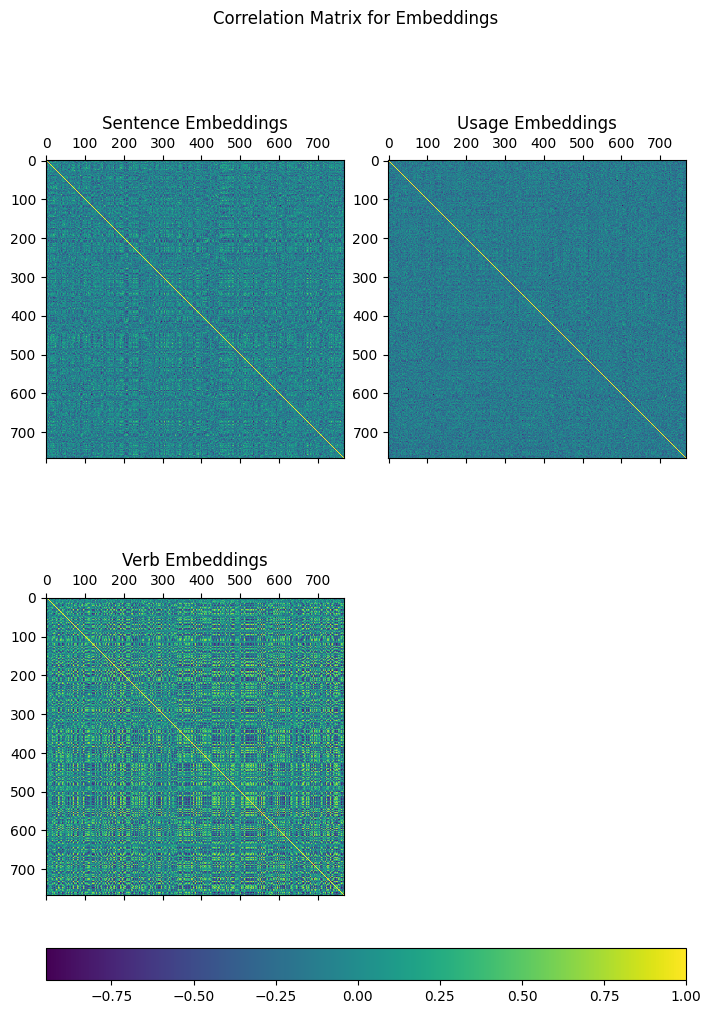

In [7]:

fig,axs = plt.subplots(2,2, figsize=(7,10), layout='constrained')
# plt.matshow(df_pca_sentence.corr(),cmap='coolwarm')

# ColorBar

from matplotlib import colors

# datasets will contain all the values of the embeddings dataframes in one numpy array
datasets = [np.concatenate((df_pca_sentence.corr().to_numpy(),
            df_pca_verb.corr().to_numpy(), 
            df_pca_usage.corr().to_numpy()), axis=1)]
# create a single norm to be shared across all images

norm = colors.Normalize(vmin=np.min(datasets), vmax=np.max(datasets))
images = []
for ax, data in zip(axs.flat, datasets):
    images.append(ax.imshow(data, norm=norm))

fig.colorbar(images[0], ax=axs, orientation='horizontal', fraction=.1)


axs[0,0].matshow(df_pca_sentence.corr())
axs[0,0].set_title('Sentence Embeddings')

axs[1,0].matshow(df_pca_verb.corr())
axs[1,0].set_title('Verb Embeddings')

axs[0,1].matshow(df_pca_usage.corr())
axs[0,1].set_title('Usage Embeddings')

axs[1,1].axis('off')

fig.suptitle('Correlation Matrix for Embeddings')

plt.show()

From here on, methods are taken from a [medium article by Wamika Jha](https://medium.com/analytics-vidhya/implementation-of-principal-component-analysis-pca-in-k-means-clustering-b4bc0aa79cb6)

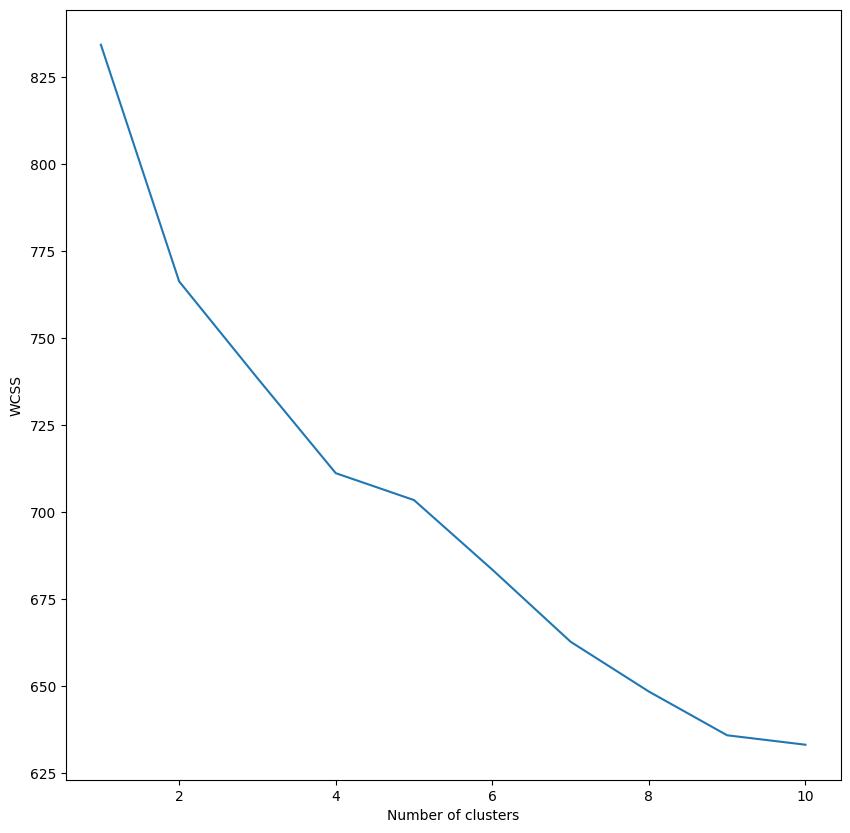

In [ ]:
wcss = []
for i in range(1,11):
   model = KMeans(n_clusters = i, init = "k-means++")
   model.fit(df_pca_sentence)
   wcss.append(model.inertia_)


fig,axs = plt.subplots(2,2, figsize=(7,10), layout='constrained')
# TODO: PLot all three

plt.figure(figsize=(10,10))
plt.plot(range(1,11), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [15]:
df_combined_embeddings = df_pca_verb.join(df_pca_usage.join(df_pca_sentence))
df_combined_embeddings.head(3)

,Verb Embeddings 1,Verb Embeddings 2,Verb Embeddings 3,Verb Embeddings 4,Verb Embeddings 5,Verb Embeddings 6,Verb Embeddings 7,Verb Embeddings 8,Verb Embeddings 9,Verb Embeddings 10,...,Sentence Embeddings 759,Sentence Embeddings 760,Sentence Embeddings 761,Sentence Embeddings 762,Sentence Embeddings 763,Sentence Embeddings 764,Sentence Embeddings 765,Sentence Embeddings 766,Sentence Embeddings 767,Sentence Embeddings 768
0,-0.028341,-0.006865,-0.008147,-0.013225,-0.034262,-0.051403,-0.034467,-0.012472,-0.062255,-0.052819,...,-0.018731,0.003891,-0.01874,0.030821,0.018223,-0.025307,-0.065967,0.010440,0.036465,-0.027924
1,-0.028341,-0.006865,-0.008147,-0.013225,-0.034262,-0.051403,-0.034467,-0.012472,-0.062255,-0.052819,...,-0.018731,0.003891,-0.01874,0.030821,0.018223,-0.025307,-0.065967,0.010440,0.036465,-0.027924
2,-0.022442,0.010922,-0.016192,-0.042995,-0.014828,-0.030193,-0.043392,-0.023752,-0.068112,-0.048461,...,0.033325,0.000843,-0.03505,-0.030099,-0.025864,-0.017886,-0.059123,-0.005189,-0.019514,-0.015873


## Classification Models

# Output